Epoch 001 | train MSE: 0.066597 | val MSE: 0.009534
Epoch 002 | train MSE: 0.010032 | val MSE: 0.002507
Epoch 003 | train MSE: 0.006285 | val MSE: 0.001744
Epoch 004 | train MSE: 0.004599 | val MSE: 0.001412
Epoch 005 | train MSE: 0.003546 | val MSE: 0.000867
Epoch 006 | train MSE: 0.002740 | val MSE: 0.000356
Epoch 007 | train MSE: 0.002183 | val MSE: 0.000319
Epoch 008 | train MSE: 0.001806 | val MSE: 0.000208
Epoch 009 | train MSE: 0.001561 | val MSE: 0.000166
Epoch 010 | train MSE: 0.001357 | val MSE: 0.000138
Epoch 011 | train MSE: 0.001188 | val MSE: 0.000240
Epoch 012 | train MSE: 0.001057 | val MSE: 0.000197
Epoch 013 | train MSE: 0.000970 | val MSE: 0.000102
Epoch 014 | train MSE: 0.000870 | val MSE: 0.000188
Epoch 015 | train MSE: 0.000803 | val MSE: 0.000086
Epoch 016 | train MSE: 0.000744 | val MSE: 0.000065
Epoch 017 | train MSE: 0.000668 | val MSE: 0.000108
Epoch 018 | train MSE: 0.000621 | val MSE: 0.000136
Epoch 019 | train MSE: 0.000576 | val MSE: 0.000062
Epoch 020 | 

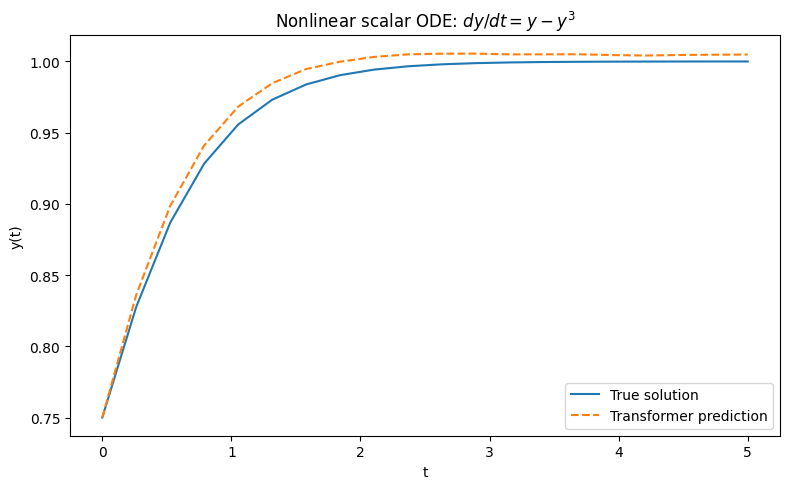

Test trajectory MSE: 0.000066


In [34]:
# transformer_1d_ode.py
# This is a short code to show how to train a small casusal Transformer-based model
# that learn to predict the trajectory of a nonlinear scalar ODE.
#
# This is the simplification of BCAT: https://arxiv.org/pdf/2501.18972
#
# Govering Equation
#     dy/dt = y - y^3
#
# This code:
#   1) generates synthetic trajectories with RK4 for the 1D ODE
#   2) trains a causal Transformer to predict the next state value
#   3) rollouts the learned model from the input condition
#   4) plots the true vs predicted trajectory
#
# The ODE is fixed once it is defined.
#
#

import math
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -----------------------------
# 1D Nonlinear ODE Solver
# -----------------------------
def ode_rhs(t, y):
    # dy/dt = y - y^2
    return y - y**3


def rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def solve_ode_rk4(f, y0, t_grid):
    y = np.zeros_like(t_grid, dtype=np.float32)
    y[0] = float(y0)
    for i in range(len(t_grid) - 1):
        dt = float(t_grid[i + 1] - t_grid[i])
        y[i + 1] = rk4_step(f, float(t_grid[i]), float(y[i]), dt)
    return y


# -----------------------------
# Generating Data
# -----------------------------
def make_trajectory_dataset(
    n_samples=3000,
    t0=0.0,
    t1=5.0,
    n_steps=30,
    y0_low=-2.0,
    y0_high=2.0,
):
    t_grid = np.linspace(t0, t1, n_steps, dtype=np.float32)
    trajectories = []
    initials = []

    for _ in range(n_samples):
        y0 = np.random.uniform(y0_low, y0_high)
        y = solve_ode_rk4(ode_rhs, y0, t_grid)
        trajectories.append(y)
        initials.append(y0)

    trajectories = np.stack(trajectories, axis=0)  # [N, T]
    initials = np.array(initials, dtype=np.float32)
    return t_grid, initials, trajectories


class TrajectoryDataset(torch.utils.data.Dataset):
    def __init__(self, t_grid, trajectories):
        """
        trajectories: [N, T]
        Autoregressive, so we need:
            input tokens  x_k = [t_k, y_k]
            target token   y_{k+1}
        and the input length is T-1 and target length is T-1.
        """
        self.t_grid = torch.tensor(t_grid, dtype=torch.float32)
        self.trajectories = torch.tensor(trajectories, dtype=torch.float32)

    def __len__(self):
        return self.trajectories.shape[0]

    def __getitem__(self, idx):
        y = self.trajectories[idx]           # [T]
        t = self.t_grid                     # [T]
        x = torch.stack([t[:-1], y[:-1]], dim=-1)   # [T-1, 2]
        target = y[1:]                      # [T-1]
        return x, target


# -----------------------------
# Transformer model
# -----------------------------
class ScalarODETransformerModel(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=3, dim_feedforward=128, max_len=128):
        super().__init__()
        self.input_proj = nn.Linear(2, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pos_emb, mean=0.0, std=0.01)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, 1)

    def causal_mask(self, seq_len):
        # Only utilize past/history, Mask future
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask

    def forward(self, x):
        """
        x: [B, L, 2] where each token is [t_k, y_k]
        returns: [B, L] predictions for y_{k+1} at each position k
        """
        B, L, _ = x.shape
        h = self.input_proj(x) + self.pos_emb[:, :L, :]
        mask = self.causal_mask(L)
        h = self.encoder(h, mask=mask)
        y_next = self.out_proj(h).squeeze(-1)  # [B, L]
        return y_next


# ---------------------------------------
# Training / evaluation helper functions
# ---------------------------------------
def train_model(model, train_loader, val_loader, epochs=30, lr=1e-2):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3) # We typically use AdamW or Muon, your choice
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0

        for x, target in train_loader:
            x = x.to(device)
            target = target.to(device)

            pred = model(x)
            loss = loss_fn(pred, target)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_loss += loss.item() * x.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, target in val_loader:
                x = x.to(device)
                target = target.to(device)
                pred = model(x)
                loss = loss_fn(pred, target)
                val_loss += loss.item() * x.size(0)

        val_loss /= len(val_loader.dataset)
        print(f"Epoch {epoch:03d} | train MSE: {train_loss:.6f} | val MSE: {val_loss:.6f}")


def rollout_model(model, t_grid, y0):
    """
    Autoregressively generate y(t) from y0.
    At step k, feed in context history [ (t_0,y_0), ... , (t_k,y_k) ]
    and use the last output to predict y_{k+1}.
    """
    model.eval()
    y_pred = np.zeros_like(t_grid, dtype=np.float32)
    y_pred[0] = float(y0)

    with torch.no_grad():
        for k in range(len(t_grid) - 1):
            prefix_t = torch.tensor(t_grid[: k + 1], dtype=torch.float32, device=device)
            prefix_y = torch.tensor(y_pred[: k + 1], dtype=torch.float32, device=device)
            x = torch.stack([prefix_t, prefix_y], dim=-1).unsqueeze(0)  # [1, k+1, 2]

            next_y = model(x)[0, -1].item()
            y_pred[k + 1] = next_y

    return y_pred


# -----------------------------
# Main
# -----------------------------
def main():
    # Make the Datasets
    t_grid, initials, trajectories = make_trajectory_dataset(
        n_samples=3000,
        t0=0.0,
        t1=5.0,
        n_steps=20,
        y0_low=0.01,
        y0_high=0.99,
    )

    # Split
    n_total = len(trajectories)
    n_train = int(0.8 * n_total)
    idx = np.random.permutation(n_total)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:]

    train_ds = TrajectoryDataset(t_grid, trajectories[train_idx])
    val_ds = TrajectoryDataset(t_grid, trajectories[val_idx])

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, shuffle=False)

    # Transformer Model, you can change parameters
    model = ScalarODETransformerModel(
        d_model=32,
        nhead=4,
        num_layers=2,
        dim_feedforward=64,
        max_len=128,
    )

    # Train the model on the training dataset
    train_model(model, train_loader, val_loader, epochs=50, lr=1e-2)

    # Test the model using rollout on new data
    test_y0 = 0.75  # I am using this as my only test value
    y_true = solve_ode_rk4(ode_rhs, test_y0, t_grid)
    y_pred = rollout_model(model, t_grid, test_y0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(t_grid, y_true, label="True solution")
    plt.plot(t_grid, y_pred, "--", label="Transformer prediction")
    plt.xlabel("t")
    plt.ylabel("y(t)")
    plt.title(r"Nonlinear scalar ODE: $dy/dt = y - y^3$")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print final error
    mse = np.mean((y_true - y_pred) ** 2)
    print(f"Test trajectory MSE: {mse:.6f}")


if __name__ == "__main__":
    main()